# Project 2: Preparing Stock Data for Machine Learning

**Student:** Mohammad Tamim Hamkar

## Introduction

In this project, I will continue working with the historical stock market data from Project 1. The goal is to clean and prepare the data for future machine learning analysis. I will review unusual values, create useful features, combine the datasets, and prepare a final dataset for Project 3.

Step 1 — Project Setup & Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 2 — Load the Two Datasets

In [2]:
# Load the Datasets Using a Manageable Sample

stocks = pd.read_csv("historical_stocks.csv")

# Load a representative sample to prevent RAM crashes
stock_prices = pd.read_csv(
    "historical_stock_prices.csv"
).sample(
    n=1000000,
    random_state=42
).copy()

print("Historical Stocks Shape:", stocks.shape)
print("Sampled Historical Stock Prices Shape:", stock_prices.shape)

Historical Stocks Shape: (6460, 5)
Sampled Historical Stock Prices Shape: (1000000, 8)


Step 3 — Inspect the Data

In [3]:
# Inspect the Datasets

print("Historical Stocks:")
display(stocks.head())

print("\nHistorical Stock Prices:")
display(stock_prices.head())

print("\nData Types:")
print(stock_prices.dtypes)

Historical Stocks:


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS



Historical Stock Prices:


,ticker,open,close,adj_close,low,high,volume,date
5481111,AAXN,17.040001,17.50,17.500000,16.790001,17.650000,1384200,2013-11-22
1273715,BOCH,4.540000,4.47,4.002714,4.470000,4.540000,17200,2012-11-27
19955602,CHNR,2.180000,2.12,2.120000,2.110000,2.180000,5000,2018-02-23
19541868,CORT,1.940000,1.99,1.990000,1.920000,2.030000,10500,2008-09-05
2011502,SR,27.850000,28.17,6.588749,27.840000,28.940001,35000,2003-10-09



Data Types:
ticker        object
open         float64
close        float64
adj_close    float64
low          float64
high         float64
volume         int64
date          object
dtype: object


Step 4 — Check Missing Values

In [4]:
# Check Missing Values

print("Missing Values in Historical Stocks:")
print(stocks.isnull().sum())

print("\nMissing Values in Historical Stock Prices:")
print(stock_prices.isnull().sum())

Missing Values in Historical Stocks:
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing Values in Historical Stock Prices:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


Step 5 — Handle Missing Values

In [5]:
# Handle Missing Values

stocks["sector"] = stocks["sector"].fillna("Unknown")
stocks["industry"] = stocks["industry"].fillna("Unknown")

print("Missing Values After Cleaning:")
print("Historical Stocks:", stocks.isnull().sum().sum())
print("Historical Stock Prices:", stock_prices.isnull().sum().sum())

Missing Values After Cleaning:
Historical Stocks: 0
Historical Stock Prices: 0


Step 6 — Detect Outliers in Closing Price and Volume

In [6]:
# Detect Outliers Using IQR

for column in ["close", "volume"]:
    Q1 = stock_prices[column].quantile(0.25)
    Q3 = stock_prices[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((stock_prices[column] < lower_bound) |
                (stock_prices[column] > upper_bound)).sum()

    print(column)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", outliers)
    print()

close
Lower Bound: -25.78125
Upper Bound: 62.96875
Number of Outliers: 80681

volume
Lower Bound: -857500.0
Upper Bound: 1488100.0
Number of Outliers: 138677



In [7]:
# Inspect the largest closing prices and trading volumes

print("Highest Closing Prices:")
display(stock_prices.nlargest(10, "close")[["ticker", "date", "close"]])

print("\nHighest Trading Volumes:")
display(stock_prices.nlargest(10, "volume")[["ticker", "date", "volume"]])

Highest Closing Prices:


,ticker,date,close
864410,CTIC,2000-10-02,775500.0
12147155,SCON,2000-06-08,650250.0
864841,CTIC,2000-12-08,465000.0
1108700,YRCW,2005-03-17,449775.0
12147135,SCON,2000-06-06,446625.0
12146807,SCON,2000-04-18,435375.0
1108421,YRCW,2005-01-31,424650.0
1108422,YRCW,2005-02-01,424500.0
1108829,YRCW,2005-05-23,396975.0
1108413,YRCW,2005-01-18,394575.0



Highest Trading Volumes:


,ticker,date,volume
1312311,FTAI,2014-09-12,3574320600
1309960,FTAI,2013-09-05,3306864000
1312267,FTAI,2014-09-05,2765935500
1309825,FTAI,2013-08-15,2578183300
1311190,FTAI,2014-02-04,2404448100
1306078,FTAI,2012-03-20,2335687400
1309359,FTAI,2013-06-06,2261018500
1310476,FTAI,2013-11-19,2218414800
1312446,FTAI,2014-10-01,2202409600
1309819,FTAI,2013-08-14,2197704700


**Step 7 — Resolve Extreme Outliers**

The dataset contains extreme values in closing prices and trading volume. Instead of removing these records, I capped the values at the 1st and 99th percentiles. This keeps the historical observations while reducing the influence of extreme values on future machine learning models.

In [8]:
# Cap Extreme Outliers

for column in ["close", "volume"]:
    lower = stock_prices[column].quantile(0.01)
    upper = stock_prices[column].quantile(0.99)

    stock_prices[column] = stock_prices[column].clip(lower, upper)

    print(column)
    print("Lower Cap:", lower)
    print("Upper Cap:", upper)
    print()

close
Lower Cap: 0.588541686534882
Upper Cap: 279.30073791504

volume
Lower Cap: 200.0
Upper Cap: 16056616.000000015



**Step 8 — Identify and Correct Data Errors**

I checked the stock-price data for invalid dates, non-positive prices, and negative trading volumes. These checks help identify records that could cause problems during analysis and machine learning.

In [9]:
# Identify Data Errors

stock_prices["date"] = pd.to_datetime(stock_prices["date"], errors="coerce")

print("Invalid Dates:", stock_prices["date"].isnull().sum())
print("Non-Positive Open Prices:", (stock_prices["open"] <= 0).sum())
print("Non-Positive Close Prices:", (stock_prices["close"] <= 0).sum())
print("Non-Positive Low Prices:", (stock_prices["low"] <= 0).sum())
print("Non-Positive High Prices:", (stock_prices["high"] <= 0).sum())
print("Negative Trading Volumes:", (stock_prices["volume"] < 0).sum())

Invalid Dates: 0
Non-Positive Open Prices: 0
Non-Positive Close Prices: 0
Non-Positive Low Prices: 0
Non-Positive High Prices: 0
Negative Trading Volumes: 0


**Step 9 — Feature Engineering**

I created several new features from the historical stock prices to make the dataset more useful for machine learning. These include price change, daily return, previous-day closing price, 5-day and 20-day moving averages, 20-day volatility, and daily range percentage. These features help describe price movements, trends, and market volatility over time.

In [10]:
# Feature Engineering

# Sort by ticker and date
stock_prices = stock_prices.sort_values(["ticker", "date"])

# 1. Price Change
stock_prices["price_change"] = (
    stock_prices.groupby("ticker")["close"].diff()
)

# 2. Daily Return
stock_prices["daily_return"] = (
    stock_prices.groupby("ticker")["close"].pct_change(fill_method=None)
)

# 3. Previous-Day Closing Price
stock_prices["close_lag_1"] = (
    stock_prices.groupby("ticker")["close"].shift(1)
)

# 4. 5-Day Moving Average
stock_prices["ma_5"] = (
    stock_prices.groupby("ticker")["close"]
    .transform(lambda x: x.rolling(5).mean())
)

# 5. 20-Day Moving Average
stock_prices["ma_20"] = (
    stock_prices.groupby("ticker")["close"]
    .transform(lambda x: x.rolling(20).mean())
)

# 6. 20-Day Volatility
stock_prices["volatility_20"] = (
    stock_prices.groupby("ticker")["daily_return"]
    .transform(lambda x: x.rolling(20).std())
)

# 7. Daily Range Percentage
stock_prices["daily_range_pct"] = (
    (stock_prices["high"] - stock_prices["low"]) / stock_prices["close"]
)

# Display the new features
stock_prices[
    [
        "ticker", "date", "close",
        "price_change", "daily_return",
        "close_lag_1", "ma_5", "ma_20",
        "volatility_20", "daily_range_pct"
    ]
].head(25)

,ticker,date,close,price_change,daily_return,close_lag_1,ma_5,ma_20,volatility_20,daily_range_pct
13766156,A,1999-12-01,30.713520,NaN,NaN,NaN,NaN,NaN,NaN,0.036390
13766331,A,2000-01-31,47.344421,16.630901,0.541485,30.713520,NaN,NaN,NaN,0.043437
13766479,A,2000-02-22,65.450645,18.106224,0.382436,47.344421,NaN,NaN,NaN,0.080601
13766924,A,2000-05-02,72.078400,6.627754,0.101263,65.450645,NaN,NaN,NaN,0.066367
13767085,A,2000-05-26,46.494991,-25.583408,-0.354939,72.078400,52.416396,NaN,NaN,0.064423
13767169,A,2000-06-08,49.445637,2.950645,0.063462,46.494991,56.162819,NaN,NaN,0.043400
13767326,A,2000-07-06,49.445637,0.000000,0.000000,49.445637,56.583062,NaN,NaN,0.030741
13768159,A,2000-11-10,28.209942,-21.235695,-0.429476,49.445637,49.134921,NaN,NaN,0.087163
13768363,A,2000-12-18,40.772533,12.562592,0.445325,28.209942,42.873748,NaN,NaN,0.033991
13768566,A,2001-01-19,46.897354,6.124821,0.150219,40.772533,42.954221,NaN,NaN,0.044805


**Step 10 — Handle Missing Values Created by Feature Engineering**

The feature engineering process created some missing values because calculations such as previous-day closing price, moving averages, and volatility require earlier observations. I removed rows with missing engineered values so that the dataset is complete before standardizing the numerical features.

In [11]:
# Handle Missing Values from Feature Engineering

engineered_features = [
    "price_change",
    "daily_return",
    "close_lag_1",
    "ma_5",
    "ma_20",
    "volatility_20"
]

print("Rows before removing missing values:", len(stock_prices))

stock_prices.dropna(
    subset=engineered_features,
    inplace=True
)

print("Rows after removing missing values:", len(stock_prices))

print(
    "Remaining missing values in engineered features:",
    stock_prices[engineered_features].isnull().sum().sum()
)

Rows before removing missing values: 1000000
Rows after removing missing values: 892459
Remaining missing values in engineered features: 0


**Step 11 — Standardize Numerical Features**

I standardized the numerical features so they are on a similar scale. This helps prevent variables with larger numerical ranges, such as trading volume, from having too much influence on machine learning models. The numerical features were standardized after handling the missing values created during feature engineering.

In [12]:
# Standardize Numerical Features - Memory Friendly

from sklearn.preprocessing import StandardScaler

features_to_scale = [
    "open", "close", "low", "high", "volume",
    "price_change", "daily_return", "close_lag_1",
    "ma_5", "ma_20", "volatility_20", "daily_range_pct"
]

# Scale one column at a time to reduce RAM usage
for column in features_to_scale:
    scaler = StandardScaler()
    stock_prices[column] = scaler.fit_transform(
        stock_prices[[column]]
    ).ravel()

print("Standardization completed successfully.")

stock_prices[features_to_scale].head(25)

Standardization completed successfully.


,open,close,low,high,volume,price_change,daily_return,close_lag_1,ma_5,ma_20,volatility_20,daily_range_pct
13770244,-0.020737,-0.305493,-0.020633,-0.020494,0.463485,-0.680162,-0.147198,-0.219351,-0.165323,0.269444,0.098912,0.090166
13770533,-0.019461,-0.240979,-0.019265,-0.019438,0.145409,0.490285,0.109640,-0.303626,-0.209580,0.228795,0.074925,-0.036653
13770658,-0.018695,-0.199942,-0.018544,-0.018611,2.105374,0.305478,0.054053,-0.239035,-0.219971,0.165396,0.059922,0.000008
13770732,-0.017437,-0.146307,-0.017416,-0.017630,0.900875,0.404642,0.067791,-0.197948,-0.220317,0.095658,0.060006,-0.045157
13770797,-0.018130,-0.164058,-0.017893,-0.017988,0.872020,-0.157292,-0.038153,-0.144249,-0.208772,0.060133,0.048976,-0.010093
13770970,-0.016452,-0.089236,-0.016325,-0.016591,1.057672,0.571420,0.092576,-0.162021,-0.165169,0.024407,0.050813,-0.056979
13771503,-0.015559,-0.058315,-0.015641,-0.015699,0.567765,0.225845,0.024949,-0.087110,-0.128339,-0.009728,0.051240,0.000450
13772305,-0.018699,-0.227045,-0.018910,-0.018861,0.377254,-1.345769,-0.214798,-0.056152,-0.133804,-0.023387,0.038580,0.043561
13772335,-0.019114,-0.235253,-0.019191,-0.019223,0.812760,-0.082167,-0.026890,-0.225084,-0.151738,-0.054718,0.011320,0.014053
13772719,-0.020008,-0.282016,-0.019931,-0.019864,0.718154,-0.385672,-0.090032,-0.233302,-0.175521,-0.096865,0.006896,0.058677


**Step 12 — Consolidate the Datasets**

I combined the historical stock-price data with the company information using the ticker symbol. This creates one dataset containing both market information and company details, which will be used for the remaining preparation steps.

In [13]:
# Consolidate the Datasets

final_data = stock_prices.merge(
    stocks,
    on="ticker",
    how="left"
)

print("Final Dataset Shape:", final_data.shape)
final_data.head()

Final Dataset Shape: (892459, 19)


,ticker,open,close,adj_close,low,high,volume,date,price_change,daily_return,close_lag_1,ma_5,ma_20,volatility_20,daily_range_pct,exchange,name,sector,industry
0,A,-0.020737,-0.305493,13.385047,-0.020633,-0.020494,0.463485,2001-10-08,-0.680162,-0.147198,-0.219351,-0.165323,0.269444,0.098912,0.090166,NYSE,"AGILENT TECHNOLOGIES, INC.",CAPITAL GOODS,BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS
1,A,-0.019461,-0.240979,15.497158,-0.019265,-0.019438,0.145409,2001-11-09,0.490285,0.109640,-0.303626,-0.209580,0.228795,0.074925,-0.036653,NYSE,"AGILENT TECHNOLOGIES, INC.",CAPITAL GOODS,BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS
2,A,-0.018695,-0.199942,16.840664,-0.018544,-0.018611,2.105374,2001-11-28,0.305478,0.054053,-0.239035,-0.219971,0.165396,0.059922,0.000008,NYSE,"AGILENT TECHNOLOGIES, INC.",CAPITAL GOODS,BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS
3,A,-0.017437,-0.146307,18.596594,-0.017416,-0.017630,0.900875,2001-12-06,0.404642,0.067791,-0.197948,-0.220317,0.095658,0.060006,-0.045157,NYSE,"AGILENT TECHNOLOGIES, INC.",CAPITAL GOODS,BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS
4,A,-0.018130,-0.164058,18.015448,-0.017893,-0.017988,0.872020,2001-12-14,-0.157292,-0.038153,-0.144249,-0.208772,0.060133,0.048976,-0.010093,NYSE,"AGILENT TECHNOLOGIES, INC.",CAPITAL GOODS,BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS


**Step 13 — Verify Missing Values After Feature Engineering**

The feature engineering process created some missing values because features such as moving averages, lag values, and volatility require previous observations. These missing values were removed earlier in the data preparation process. In this step, I verified the final dataset to make sure there were no remaining missing values in the engineered features before continuing with the analysis and machine learning.

In [14]:
# Verify Missing Values After Feature Engineering

engineered_features = [
    "price_change",
    "daily_return",
    "close_lag_1",
    "ma_5",
    "ma_20",
    "volatility_20"
]

print("Final Dataset Shape:", final_data.shape)

print(
    "Remaining Missing Values in Engineered Features:",
    final_data[engineered_features].isnull().sum().sum()
)

Final Dataset Shape: (892459, 19)
Remaining Missing Values in Engineered Features: 0


Step 14 — Encode Categorical Variables

The exchange and sector columns are categorical, so I converted them into numerical variables using one-hot encoding. This creates separate binary columns for each category instead of assigning arbitrary numerical rankings. One-hot encoding is more appropriate because categories such as NASDAQ, NYSE, and different sectors do not have a natural numerical order.

In [15]:
# One-Hot Encode Categorical Variables

final_data = pd.get_dummies(
    final_data,
    columns=["exchange", "sector"],
    prefix=["exchange", "sector"],
    dtype=int
)

print("Dataset Shape After One-Hot Encoding:", final_data.shape)

# Display the new encoded columns
encoded_columns = [
    col for col in final_data.columns
    if col.startswith("exchange_") or col.startswith("sector_")
]

print("Encoded Columns:")
print(encoded_columns)

Dataset Shape After One-Hot Encoding: (892459, 32)
Encoded Columns:
['exchange_NASDAQ', 'exchange_NYSE', 'sector_BASIC INDUSTRIES', 'sector_CAPITAL GOODS', 'sector_CONSUMER DURABLES', 'sector_CONSUMER NON-DURABLES', 'sector_CONSUMER SERVICES', 'sector_ENERGY', 'sector_FINANCE', 'sector_HEALTH CARE', 'sector_MISCELLANEOUS', 'sector_PUBLIC UTILITIES', 'sector_TECHNOLOGY', 'sector_TRANSPORTATION', 'sector_Unknown']


**Step 15 — Split the Data**

I divided the prepared dataset into training, validation, and test sets using a 70%, 15%, and 15% split. The training set will be used to train the machine learning model, the validation set will help evaluate and improve the model, and the test set will be used for final evaluation.

In [16]:
# Split Data into Training, Validation, and Test Sets

n = len(final_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = final_data.iloc[:train_end]
val_data = final_data.iloc[train_end:val_end]
test_data = final_data.iloc[val_end:]

print("Training Set:", train_data.shape)
print("Validation Set:", val_data.shape)
print("Test Set:", test_data.shape)

Training Set: (624721, 32)
Validation Set: (133869, 32)
Test Set: (133869, 32)


**Step 16 — Save the Prepared Data**

I saved the final cleaned dataset and the training, validation, and test sets as separate CSV files. These files can now be used for future machine learning analysis and modeling.

In [23]:
# Save Cleaned Data and Data Splits

final_data.to_csv("stock_prepared.csv", index=False)
train_data.to_csv("train_data.csv", index=False)
val_data.to_csv("validation_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)

print("All cleaned datasets were saved successfully.")

All cleaned datasets were saved successfully.


**Step 17 — Visualize the Cleaned Data**

I used a sample of the cleaned dataset to visualize the distribution of scaled closing prices after outlier treatment. The boxplot shows that most closing prices are concentrated within a smaller range, while some higher values remain. This indicates that the data is right-skewed even after extreme values were capped and the closing prices were standardized.

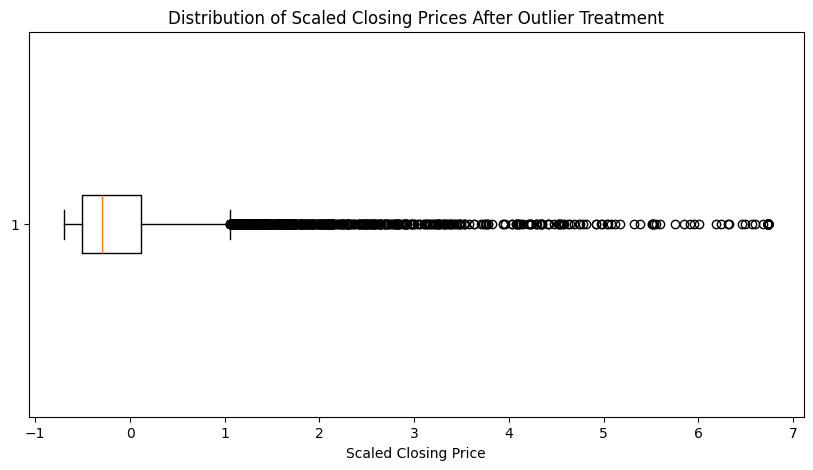

In [24]:
# Visualize Cleaned and Scaled Closing Prices

sample_data = final_data["close"].sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(10, 5))
plt.boxplot(sample_data, vert=False)

plt.title("Distribution of Scaled Closing Prices After Outlier Treatment")
plt.xlabel("Scaled Closing Price")
plt.show()

**Step 18 — Statistical Analysis of Cleaned Data**

I calculated descriptive statistics for 100,000 rows of the main numerical variables to better understand their distribution after data cleaning, outlier treatment, feature engineering, and scaling. I limited the analysis to 100,000 rows to make it more memory-efficient while examining measures such as the mean, standard deviation, minimum, maximum, and quartiles.

In [25]:
# Statistical Analysis of Cleaned Data
# Read only a sample from the saved cleaned dataset to avoid RAM problems

import pandas as pd

columns_to_analyze = [
    "open",
    "close",
    "low",
    "high",
    "volume",
    "daily_return",
    "ma_20",
    "volatility_20"
]

sample_data = pd.read_csv(
    "cleaned_stock_data.csv",
    usecols=columns_to_analyze,
    nrows=100000
)

statistics = sample_data.describe().round(4)

print("Descriptive Statistics (100,000 Row Sample):")
display(statistics)

Descriptive Statistics (100,000 Row Sample):


,open,close,low,high,volume,daily_return,ma_20,volatility_20
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.0018,0.0333,0.0017,0.0018,0.0992,-0.0013,0.0350,0.0032
std,0.3859,1.0938,0.3824,0.3876,1.1441,0.4420,1.0969,0.6183
min,-0.0284,-0.6986,-0.0282,-0.0284,-0.4032,-0.7881,-0.7013,-0.1056
25%,-0.0248,-0.5279,-0.0247,-0.0248,-0.3906,-0.0419,-0.5218,-0.0573
50%,-0.0203,-0.2926,-0.0202,-0.0203,-0.3210,-0.0124,-0.2863,-0.0309
75%,-0.0122,0.1329,-0.0121,-0.0122,-0.0136,0.0242,0.1247,0.0105
max,23.6401,6.7385,23.7286,23.6777,6.3211,91.1422,6.9525,84.0432


**Interpretation:**

The descriptive statistics summarize 100,000 rows from the cleaned dataset. The results show the count, mean, standard deviation, minimum, maximum, and quartiles for the main numerical variables. Since the numerical features were standardized earlier, many values are centered near zero. The results also show that some variables still have a wide range of standardized values, reflecting the variation present in the stock market data.

**Step 19 — Correlation Analysis**

I analyzed the correlations between the main numerical variables to understand how they are related. I used 100,000 rows from the cleaned dataset to reduce memory usage while still providing a useful view of the relationships between the variables.

In [26]:
# Correlation Analysis

correlation = sample_data.corr()

print("Correlation Matrix:")
display(correlation.round(3))

Correlation Matrix:


,open,close,low,high,volume,daily_return,ma_20,volatility_20
open,1.000,0.306,1.000,1.000,-0.015,0.007,0.310,-0.005
close,0.306,1.000,0.306,0.306,0.014,0.025,0.952,-0.014
low,1.000,0.306,1.000,1.000,-0.015,0.008,0.310,-0.005
high,1.000,0.306,1.000,1.000,-0.015,0.007,0.310,-0.005
volume,-0.015,0.014,-0.015,-0.015,1.000,-0.001,0.008,-0.007
daily_return,0.007,0.025,0.008,0.007,-0.001,1.000,-0.010,0.183
ma_20,0.310,0.952,0.310,0.310,0.008,-0.010,1.000,-0.010
volatility_20,-0.005,-0.014,-0.005,-0.005,-0.007,0.183,-0.010,1.000


**Interpretation: **

The correlation analysis shows that some stock-price variables are strongly related. Open, high, and low prices have correlations very close to 1.000, showing that they move closely together. Closing price also has a strong positive relationship with the 20-day moving average, with a correlation of 0.952. Most other variables have weak correlations, while daily return and 20-day volatility have a small positive relationship of 0.183. Overall, the results help identify which variables move together and which provide more independent information for future analysis.

**Step 20 — Correlation Heatmap**

I created a correlation heatmap to visually compare the relationships between the numerical variables. This makes it easier to identify strong positive and negative correlations in the cleaned dataset.

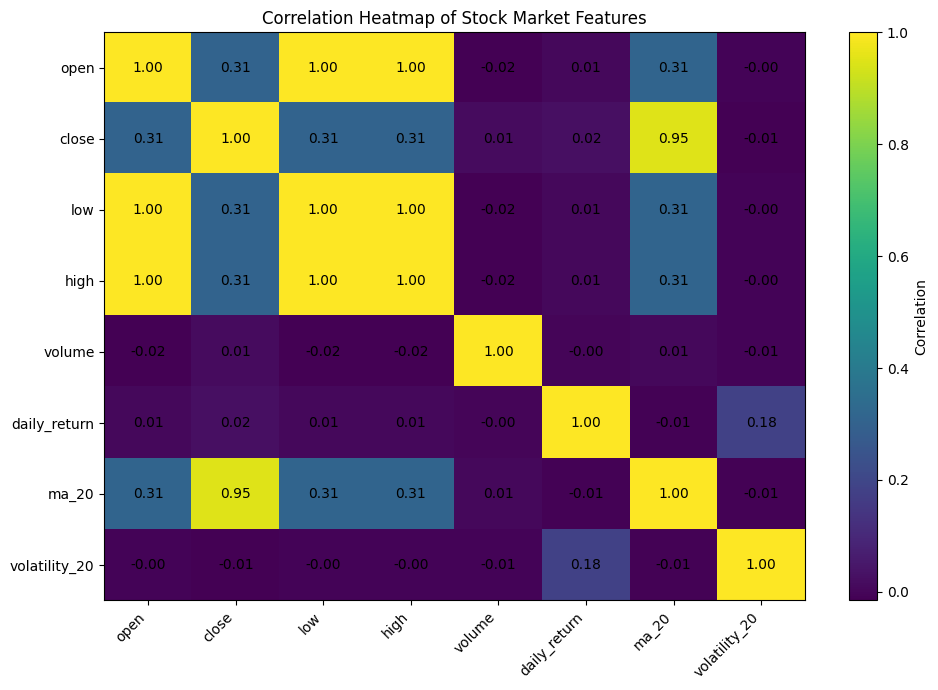

In [27]:
# Correlation Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Add correlation values inside the heatmap
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap of Stock Market Features")
plt.tight_layout()
plt.show()

**Interpretation:**

The correlation heatmap makes it easier to see the relationships between the numerical variables. Open, high, and low prices show very strong positive correlations, while closing price and the 20-day moving average also have a strong positive relationship. Daily return and 20-day volatility have a weaker positive relationship. Most other variables show little or no correlation. This visualization helps identify which features are closely related and which provide different information about the stock market data.

**Step 21 — Final Dataset Check**

Before saving the final prepared dataset, I performed final checks to confirm that the data is complete and suitable for use in Project 3. I checked the dataset size, data types, missing values, duplicate ticker-date records, and the minimum and maximum dates.

In [28]:
# Final Dataset Checks

print("Final Dataset Shape:", final_data.shape)

print("\nData Types:")
print(final_data.dtypes)

print("\nTotal Missing Values:")
print(final_data.isnull().sum().sum())

print("\nDuplicate Ticker + Date Records:")
print(final_data.duplicated(subset=["ticker", "date"]).sum())

print("\nMinimum Date:", final_data["date"].min())
print("Maximum Date:", final_data["date"].max())

Final Dataset Shape: (892459, 32)

Data Types:
ticker                                  object
open                                   float64
close                                  float64
adj_close                              float64
low                                    float64
high                                   float64
volume                                 float64
date                            datetime64[ns]
price_change                           float64
daily_return                           float64
close_lag_1                            float64
ma_5                                   float64
ma_20                                  float64
volatility_20                          float64
daily_range_pct                        float64
name                                    object
industry                                object
exchange_NASDAQ                          int64
exchange_NYSE                            int64
sector_BASIC INDUSTRIES                  int64
sector_CAPITA

**Interpretation:**

The final prepared dataset contains 892,459 rows and 32 columns. The data types are appropriate for the analysis, including numerical variables, a datetime variable, and one-hot encoded categorical variables. The final dataset has no missing values and no duplicate ticker-date records. The data covers the period from November 18, 1970 to August 24, 2018. These final checks confirm that the dataset has been properly cleaned, transformed, and prepared for use in the next machine learning project.

**Step 22 — Documentation and Findings**

1. Missing Values

I found some missing values during the cleaning and feature engineering process. Moving averages, lag values, and volatility also created missing values because they need previous data. I removed these missing values, and the final dataset has 0 missing values.

2. Missing or Suspicious Data

I checked the data for missing information, unusual values, and duplicates. I used the same cleaning approach throughout the dataset. After cleaning, there were 0 duplicate ticker-date records.

3. Outliers

I found some extreme values in stock prices, volume, daily returns, and volatility. I treated the outliers to reduce their effect while keeping useful information in the dataset.

4. New Features

I created features such as price change, daily return, lag closing price, 5-day and 20-day moving averages, volatility, and daily price range percentage. These features help describe stock movement and trends.

5. Transformations

I standardized the numerical features so they were on a similar scale. I also used one-hot encoding for exchange and sector information so these categories could be used in machine learning.

6. Final Dataset

My final dataset has 892,459 rows and 32 columns, with 0 missing values and 0 duplicate ticker-date records. The data covers November 18, 1970 to August 24, 2018, and it is now prepared for future machine learning analysis.